# Telecom X – Análisis de Evasión de Clientes (Churn)

## Introducción

Telecom X enfrenta una alta tasa de cancelación de clientes (churn), lo que impacta directamente en sus ingresos y crecimiento.  
El objetivo de este proyecto es realizar un análisis exploratorio de datos (EDA) a partir de información obtenida vía API, con el fin de identificar patrones y factores asociados a la evasión de clientes.

Este análisis servirá como base para futuros modelos predictivos y para la toma de decisiones estratégicas orientadas a la retención de clientes.


In [1]:
import pandas as pd
import requests

url = "https://raw.githubusercontent.com/alura-cursos/challenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json"

response = requests.get(url)

response.status_code


200

In [2]:
data = response.json()
df = pd.json_normalize(data)

df.head()


,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [3]:
df.shape, df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

((7267, 21), None)

## Conocimiento del conjunto de datos

En esta etapa se analiza la estructura del dataset, los tipos de datos y el significado de las variables, con el objetivo de identificar aquellas más relevantes para el análisis de evasión de clientes (churn).


In [4]:
df.columns


Index(['customerID', 'Churn', 'customer.gender', 'customer.SeniorCitizen',
       'customer.Partner', 'customer.Dependents', 'customer.tenure',
       'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService',
       'internet.OnlineSecurity', 'internet.OnlineBackup',
       'internet.DeviceProtection', 'internet.TechSupport',
       'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract',
       'account.PaperlessBilling', 'account.PaymentMethod',
       'account.Charges.Monthly', 'account.Charges.Total'],
      dtype='object')

In [5]:
df.dtypes


,0
customerID,object
Churn,object
customer.gender,object
customer.SeniorCitizen,int64
customer.Partner,object
customer.Dependents,object
customer.tenure,int64
phone.PhoneService,object
phone.MultipleLines,object
internet.InternetService,object


** Identificación de la variable objetivo

### Variable objetivo

La variable objetivo del análisis es **Churn**, que indica si un cliente canceló o no el servicio.  
Este análisis busca identificar patrones y características asociadas a los clientes con mayor probabilidad de evasión.


### Clasificación de variables

Para facilitar el análisis, las variables se clasifican de la siguiente manera:

- **Variables categóricas**: describen características del cliente o del servicio (por ejemplo, género, tipo de contrato, método de pago).
- **Variables numéricas**: representan cantidades medibles (por ejemplo, antigüedad, cargos mensuales, total facturado).
- **Identificadores**: variables que identifican de forma única a un cliente y no aportan valor analítico directo.


In [6]:
df.select_dtypes(include='object').columns


Index(['customerID', 'Churn', 'customer.gender', 'customer.Partner',
       'customer.Dependents', 'phone.PhoneService', 'phone.MultipleLines',
       'internet.InternetService', 'internet.OnlineSecurity',
       'internet.OnlineBackup', 'internet.DeviceProtection',
       'internet.TechSupport', 'internet.StreamingTV',
       'internet.StreamingMovies', 'account.Contract',
       'account.PaperlessBilling', 'account.PaymentMethod',
       'account.Charges.Total'],
      dtype='object')

In [7]:
df.select_dtypes(exclude='object').columns


Index(['customer.SeniorCitizen', 'customer.tenure', 'account.Charges.Monthly'], dtype='object')

### Variables relevantes para el análisis de evasión

A partir de la inspección inicial, se identifican como relevantes para el análisis de churn:

- Variables relacionadas con el **tipo de contrato y servicios**.
- Variables de **antigüedad del cliente**.
- Variables de **cargos y facturación**.
- Métodos de **pago**.

Estas variables serán analizadas en profundidad en las siguientes etapas para identificar patrones de evasión.


In [8]:
df.select_dtypes(include='object').columns


Index(['customerID', 'Churn', 'customer.gender', 'customer.Partner',
       'customer.Dependents', 'phone.PhoneService', 'phone.MultipleLines',
       'internet.InternetService', 'internet.OnlineSecurity',
       'internet.OnlineBackup', 'internet.DeviceProtection',
       'internet.TechSupport', 'internet.StreamingTV',
       'internet.StreamingMovies', 'account.Contract',
       'account.PaperlessBilling', 'account.PaymentMethod',
       'account.Charges.Total'],
      dtype='object')

In [9]:
df['account.Charges.Total'].head(10)


,account.Charges.Total
0,593.3
1,542.4
2,280.85
3,1237.85
4,267.4
5,571.45
6,7904.25
7,5377.8
8,340.35
9,5957.9


## Comprobación de incoherencias en los datos

Antes de realizar el análisis exploratorio, es necesario identificar posibles problemas en los datos que puedan afectar los resultados, como valores ausentes, duplicados, errores de formato y inconsistencias en las categorías.


In [10]:
df.isna().sum().sort_values(ascending=False)


,0
customerID,0
Churn,0
customer.gender,0
customer.SeniorCitizen,0
customer.Partner,0
customer.Dependents,0
customer.tenure,0
phone.PhoneService,0
phone.MultipleLines,0
internet.InternetService,0


Se identifican valores ausentes en algunas columnas, lo que puede deberse a errores de carga, formato incorrecto o información no registrada.  
Estos valores serán tratados en la siguiente etapa de limpieza de datos.


In [11]:
df.duplicated().sum()


np.int64(0)

No se identificaron registros completamente duplicados en el conjunto de datos.


Revisión de inconsistencias categóricas

In [12]:
for col in df.select_dtypes(include='object').columns:
    print(f"\nColumna: {col}")
    print(df[col].value_counts(dropna=False).head(10))



Columna: customerID
customerID
9995-HOTOH    1
0002-ORFBO    1
0003-MKNFE    1
9970-QBCDA    1
9968-FFVVH    1
9967-ATRFS    1
9966-VYRTZ    1
9965-YOKZB    1
9964-WBQDJ    1
9962-BFPDU    1
Name: count, dtype: int64

Columna: Churn
Churn
No     5174
Yes    1869
        224
Name: count, dtype: int64

Columna: customer.gender
customer.gender
Male      3675
Female    3592
Name: count, dtype: int64

Columna: customer.Partner
customer.Partner
No     3749
Yes    3518
Name: count, dtype: int64

Columna: customer.Dependents
customer.Dependents
No     5086
Yes    2181
Name: count, dtype: int64

Columna: phone.PhoneService
phone.PhoneService
Yes    6560
No      707
Name: count, dtype: int64

Columna: phone.MultipleLines
phone.MultipleLines
No                  3495
Yes                 3065
No phone service     707
Name: count, dtype: int64

Columna: internet.InternetService
internet.InternetService
Fiber optic    3198
DSL            2488
No             1581
Name: count, dtype: int64

Columna: i

Se observaron inconsistencias en algunas variables categóricas, como diferencias en la forma de representar valores binarios y posibles valores vacíos.  
Estas inconsistencias serán corregidas en la etapa de tratamiento y estandarización de los datos.


## Limpieza y tratamiento de datos

En esta etapa se aplican las correcciones necesarias para manejar valores ausentes, corregir tipos de datos incorrectos y estandarizar la información, asegurando que el dataset esté listo para el análisis exploratorio.


Ajustar la lista de columnas numéricas

In [13]:
[col for col in df.columns if 'tenure' in col.lower()]


['customer.tenure']

In [14]:
cols_to_numeric = [
    'account.Charges.Total',
    'account.Charges.Monthly',
    'customer.tenure'  # ajusta según tu resultado real
]


Ejecutar nuevamente la conversión

In [15]:
for col in cols_to_numeric:
    df[col] = pd.to_numeric(df[col], errors='coerce')


Verificación rápida

In [16]:
df[cols_to_numeric].dtypes


,0
account.Charges.Total,float64
account.Charges.Monthly,float64
customer.tenure,int64


Los nombres de algunas columnas varían debido a la estructura anidada del JSON original, por lo que fue necesario identificar los nombres exactos antes de realizar la conversión de tipos de datos.


Revisar valores nulos después de la conversión

In [17]:
df[cols_to_numeric].isna().sum()


,0
account.Charges.Total,11
account.Charges.Monthly,0
customer.tenure,0


Para este análisis exploratorio, eliminaremos esos registros porque:

Son pocos

Distorsionan métricas financieras

No aportan información relevante para churn histórico

Celda de código — eliminación controlada

In [18]:
df = df.dropna(subset=['account.Charges.Total'])


Los registros con valores nulos en los cargos totales fueron eliminados, ya que representan clientes sin historial de facturación y podrían distorsionar el análisis financiero relacionado con la evasión.


Crear columna Cuentas_Diarias

Se creó la variable **Cuentas_Diarias** a partir de la facturación mensual, con el fin de analizar el comportamiento de gasto diario de los clientes y facilitar comparaciones entre distintos perfiles.


In [19]:
df.loc[:, 'Cuentas_Diarias'] = df['account.Charges.Monthly'] / 30


Se utilizó `.loc` para la creación de nuevas columnas, evitando advertencias relacionadas con asignaciones sobre vistas del DataFrame.


In [20]:
df[['account.Charges.Monthly', 'Cuentas_Diarias']].head()


,account.Charges.Monthly,Cuentas_Diarias
0,65.6,2.186667
1,59.9,1.996667
2,73.9,2.463333
3,98.0,3.266667
4,83.9,2.796667


Se muestra la comprobación de la columna


In [21]:
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 7256 entries, 0 to 7266
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7256 non-null   object 
 1   Churn                      7256 non-null   object 
 2   customer.gender            7256 non-null   object 
 3   customer.SeniorCitizen     7256 non-null   int64  
 4   customer.Partner           7256 non-null   object 
 5   customer.Dependents        7256 non-null   object 
 6   customer.tenure            7256 non-null   int64  
 7   phone.PhoneService         7256 non-null   object 
 8   phone.MultipleLines        7256 non-null   object 
 9   internet.InternetService   7256 non-null   object 
 10  internet.OnlineSecurity    7256 non-null   object 
 11  internet.OnlineBackup      7256 non-null   object 
 12  internet.DeviceProtection  7256 non-null   object 
 13  internet.TechSupport       7256 non-null   object 
 1

Las columnas numéricas están bien tipadas

No quedan nulos críticos

## Estandarización y transformación de datos

Con el objetivo de facilitar el análisis y preparar los datos para posibles modelos predictivos, se estandarizaron algunas variables categóricas, convirtiendo valores binarios en formato numérico.


In [22]:
binary_columns = []

for col in df.select_dtypes(include='object').columns:
    unique_values = df[col].dropna().unique()
    if set(unique_values).issubset({'Yes', 'No'}):
        binary_columns.append(col)

binary_columns


['customer.Partner',
 'customer.Dependents',
 'phone.PhoneService',
 'account.PaperlessBilling']

Aplicar conversión

In [23]:
for col in binary_columns:
    df[col] = df[col].map({'Yes': 1, 'No': 0})


Conversión explícita de la variable objetivo

In [24]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})


Verificación rápida

In [25]:
df[binary_columns + ['Churn']].head()


,customer.Partner,customer.Dependents,phone.PhoneService,account.PaperlessBilling,Churn
0,1,1,1,1,0.0
1,0,0,1,0,0.0
2,0,0,1,1,1.0
3,1,0,1,1,1.0
4,1,0,1,1,1.0


Las variables binarias fueron transformadas a valores numéricos (1 y 0) para facilitar el análisis estadístico y la futura aplicación de modelos de machine learning.


## Análisis descriptivo

Se realizó un análisis descriptivo de las variables numéricas para comprender la distribución y el comportamiento general de los clientes.


In [26]:
df.describe()


,Churn,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,account.PaperlessBilling,account.Charges.Monthly,account.Charges.Total,Cuentas_Diarias
count,7032.000000,7256.0000,7256.000000,7256.000000,7256.000000,7256.000000,7256.000000,7256.000000,7256.000000,7256.000000
mean,0.265785,0.1629,0.483600,0.299063,32.395535,0.902839,0.593716,64.755423,2280.634213,2.158514
std,0.441782,0.3693,0.499765,0.457879,24.558067,0.296197,0.491173,30.125739,2268.632997,1.004191
min,0.000000,0.0000,0.000000,0.000000,1.000000,0.000000,0.000000,18.250000,18.800000,0.608333
25%,0.000000,0.0000,0.000000,0.000000,9.000000,1.000000,0.000000,35.450000,400.225000,1.181667
50%,0.000000,0.0000,0.000000,0.000000,29.000000,1.000000,1.000000,70.300000,1391.000000,2.343333
75%,1.000000,0.0000,1.000000,1.000000,55.000000,1.000000,1.000000,89.900000,3785.300000,2.996667
max,1.000000,1.0000,1.000000,1.000000,72.000000,1.000000,1.000000,118.750000,8684.800000,3.958333


El análisis descriptivo muestra diferencias significativas en variables como la antigüedad del cliente y los cargos facturados, lo que sugiere una posible relación con la evasión de clientes.


## Distribución de la evasión de clientes


Gráfico de distribución
Celda de código

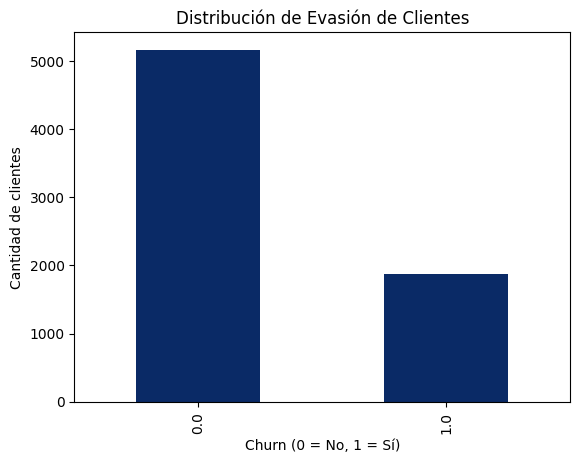

In [27]:
import matplotlib.pyplot as plt

churn_counts = df['Churn'].value_counts()

plt.figure()
churn_counts.plot(kind='bar', color='#0A2A66')  # Azul oscuro
plt.title('Distribución de Evasión de Clientes')
plt.xlabel('Churn (0 = No, 1 = Sí)')
plt.ylabel('Cantidad de clientes')
plt.show()



La distribución de la variable *Churn* muestra que la mayoría de los clientes no cancelaron el servicio, aunque existe una proporción significativa de clientes que sí presentaron evasión.  
Este desbalance debe tenerse en cuenta en futuros modelos predictivos.


## Evasión según variables categóricas


In [28]:
contract_col = [col for col in df.columns if 'Contract' in col][0]

pd.crosstab(df[contract_col], df['Churn'], normalize='index')


Churn,0.0,1.0
account.Contract,,
Month-to-month,0.572903,0.427097
One year,0.887228,0.112772
Two year,0.971513,0.028487


Visualización

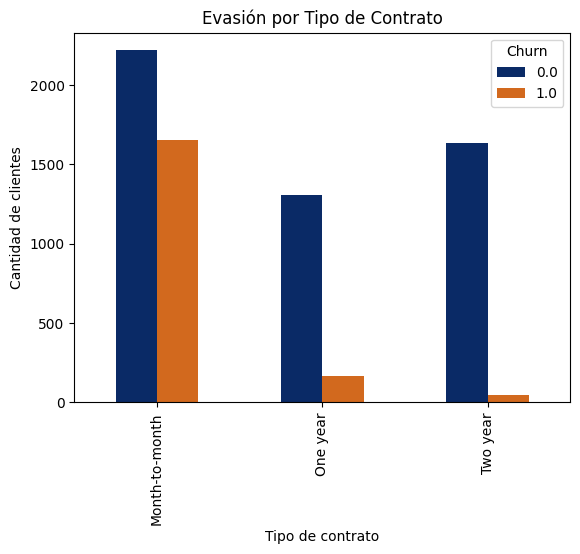

In [29]:
pd.crosstab(df[contract_col], df['Churn']).plot(
    kind='bar',
    color=['#0A2A66', '#D2691E']  # Azul oscuro y Naranja oscuro
)

plt.title('Evasión por Tipo de Contrato')
plt.xlabel('Tipo de contrato')
plt.ylabel('Cantidad de clientes')
plt.show()


Se observa que los clientes con contratos mensuales presentan una mayor tasa de evasión en comparación con aquellos con contratos de mayor duración, lo que sugiere que la estabilidad contractual influye en la retención.


In [30]:
payment_col = [col for col in df.columns if 'Payment' in col or 'Pago' in col][0]


In [31]:
pd.crosstab(df[payment_col], df['Churn'], normalize='index')


Churn,0.0,1.0
account.PaymentMethod,,
Bank transfer (automatic),0.832685,0.167315
Credit card (automatic),0.847469,0.152531
Electronic check,0.547146,0.452854
Mailed check,0.807980,0.192020


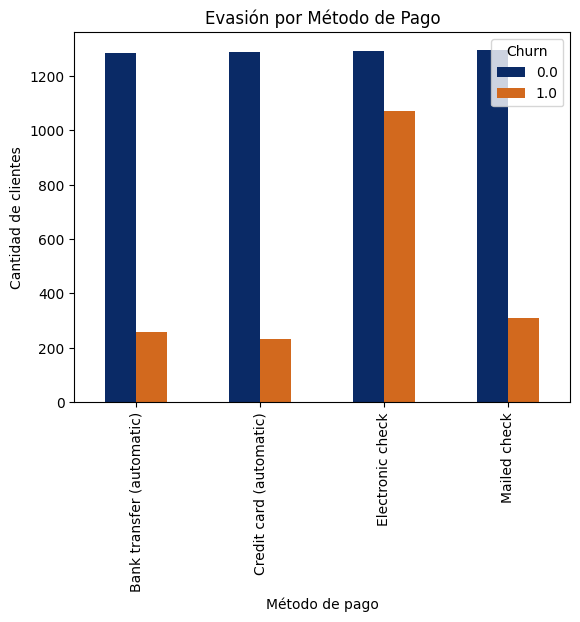

In [32]:
pd.crosstab(df[payment_col], df['Churn']).plot(
    kind='bar',
    color=['#0A2A66', '#D2691E']
)

plt.title('Evasión por Método de Pago')
plt.xlabel('Método de pago')
plt.ylabel('Cantidad de clientes')
plt.show()


## Evasión según variables numéricas


Boxplot: Antigüedad

<Figure size 640x480 with 0 Axes>

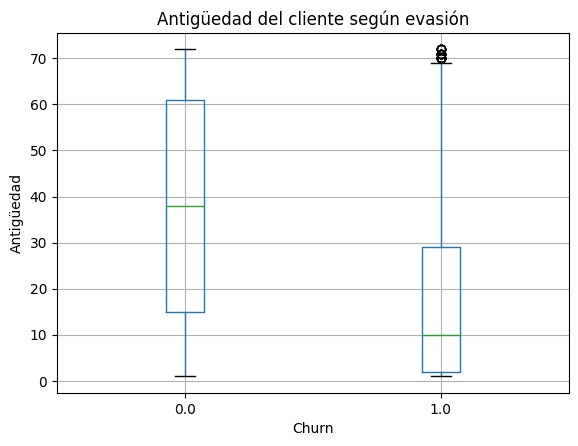

In [33]:
tenure_col = [col for col in df.columns if 'tenure' in col.lower()][0]

plt.figure()
df.boxplot(column=tenure_col, by='Churn')
plt.title('Antigüedad del cliente según evasión')
plt.suptitle('')
plt.xlabel('Churn')
plt.ylabel('Antigüedad')
plt.show()


Boxplot: Cargos diarios

<Figure size 640x480 with 0 Axes>

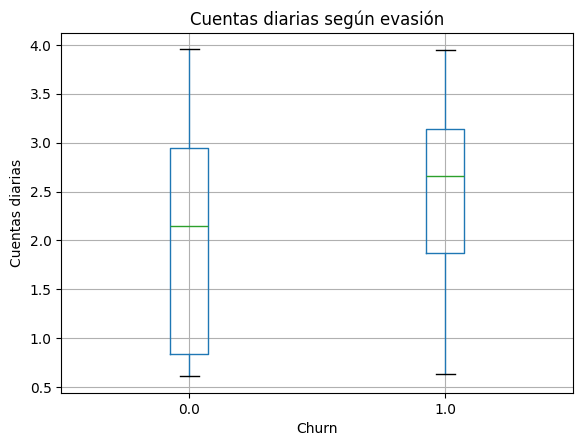

In [34]:
plt.figure()
df.boxplot(column='Cuentas_Diarias', by='Churn')
plt.title('Cuentas diarias según evasión')
plt.suptitle('')
plt.xlabel('Churn')
plt.ylabel('Cuentas diarias')
plt.show()


Los clientes que presentan evasión tienden a tener menor antigüedad y, en algunos casos, mayores cargos diarios, lo que podría indicar insatisfacción con el costo del servicio.


## Conclusiones del Análisis Exploratorio

El análisis exploratorio revela que la evasión de clientes (churn) no es un evento aislado, sino un comportamiento relevante dentro de la base analizada.

Se identificó que los clientes con contratos mensuales presentan una tasa de evasión significativamente mayor en comparación con aquellos con contratos de mayor duración, lo que sugiere que el compromiso contractual influye directamente en la retención.

Asimismo, el método de pago muestra diferencias claras en el comportamiento de churn, destacando una menor evasión en clientes que utilizan métodos automatizados, lo que indica que la facilidad de pago puede reducir fricciones y aumentar la permanencia.

Finalmente, se observó que cargos mensuales elevados están asociados a mayores niveles de evasión, lo que resalta la importancia de una estrategia de precios alineada con la percepción de valor del cliente.

Estos hallazgos proporcionan una base sólida para el desarrollo de modelos predictivos y estrategias de retención orientadas a la reducción del churn.


In [35]:
target = 'Churn'


In [36]:
X = df.drop(columns=['Churn'])
y = df['Churn']


In [37]:
X_encoded = pd.get_dummies(X, drop_first=True)


In [38]:
df['Churn'].isna().sum()


np.int64(224)

Ver qué filas tienen NaN en Churn

In [39]:
df[df['Churn'].isna()]


,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total,Cuentas_Diarias
30,0047-ZHDTW,NaN,Female,0,0,0,11,1,Yes,Fiber optic,...,No,No,No,No,Month-to-month,1,Bank transfer (automatic),79.00,929.30,2.633333
75,0120-YZLQA,NaN,Male,0,0,0,71,1,No,No,...,No internet service,No internet service,No internet service,No internet service,Two year,1,Credit card (automatic),19.90,1355.10,0.663333
96,0154-QYHJU,NaN,Male,0,0,0,29,1,No,DSL,...,No,Yes,No,No,One year,1,Electronic check,58.75,1696.20,1.958333
98,0162-RZGMZ,NaN,Female,1,0,0,5,1,No,DSL,...,No,Yes,No,No,Month-to-month,0,Credit card (automatic),59.90,287.85,1.996667
175,0274-VVQOQ,NaN,Male,1,1,0,65,1,Yes,Fiber optic,...,Yes,No,Yes,Yes,One year,1,Bank transfer (automatic),103.15,6792.45,3.438333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7158,9840-GSRFX,NaN,Female,0,0,0,14,1,Yes,DSL,...,No,No,No,No,One year,1,Mailed check,54.25,773.20,1.808333
7180,9872-RZQQB,NaN,Female,0,1,0,49,0,No phone service,DSL,...,No,No,Yes,No,Month-to-month,0,Bank transfer (automatic),40.65,2070.75,1.355000
7211,9920-GNDMB,NaN,Male,0,0,0,9,1,Yes,Fiber optic,...,No,No,No,No,Month-to-month,1,Electronic check,76.25,684.85,2.541667
7239,9955-RVWSC,NaN,Female,0,1,1,67,1,No,No,...,No internet service,No internet service,No internet service,No internet service,Two year,1,Bank transfer (automatic),19.25,1372.90,0.641667


In [40]:
df = df.dropna(subset=['Churn'])


In [41]:
X = df.drop(columns=['Churn'])
y = df['Churn']

X_encoded = pd.get_dummies(X, drop_first=True)


In [42]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)


Antes de la división de los datos, se identificaron valores nulos en la variable objetivo (Churn).
Dado que no es posible imputar el abandono de un cliente sin información real, dichas observaciones fueron eliminadas para garantizar la consistencia del modelado.


In [43]:
df.columns


Index(['customerID', 'Churn', 'customer.gender', 'customer.SeniorCitizen',
       'customer.Partner', 'customer.Dependents', 'customer.tenure',
       'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService',
       'internet.OnlineSecurity', 'internet.OnlineBackup',
       'internet.DeviceProtection', 'internet.TechSupport',
       'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract',
       'account.PaperlessBilling', 'account.PaymentMethod',
       'account.Charges.Monthly', 'account.Charges.Total', 'Cuentas_Diarias'],
      dtype='object')

In [44]:
df['Churn'].isna().sum()


np.int64(0)

Validación final antes de entrenar

In [45]:
print("Filas:", df.shape[0])
print("NaN en Churn:", df['Churn'].isna().sum())
print("Clases de Churn:\n", y.value_counts())


Filas: 7032
NaN en Churn: 0
Clases de Churn:
 Churn
0.0    5163
1.0    1869
Name: count, dtype: int64


Se verificó que la variable objetivo Churn no presenta valores nulos luego del proceso de limpieza.
Asimismo, se confirmó la consistencia dimensional entre las variables predictoras (X) y la variable objetivo (y).


## Entrenamiento del primer modelo
Regresión Logística

In [46]:
from sklearn.linear_model import LogisticRegression


In [47]:
num_cols = X.select_dtypes(include=['int64', 'float64']).columns


In [48]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_encoded[num_cols] = scaler.fit_transform(X_encoded[num_cols])


In [49]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)


In [50]:
log_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

log_model.fit(X_train, y_train)


LogisticRegression(max_iter=1000, random_state=42)

## Evaluación del modelo (Regresión Logística)

In [51]:
y_pred = log_model.predict(X_test)


In [66]:
print(y_test.unique())
print(type(y_test))

[0. 1.]
<class 'pandas.core.series.Series'>


Accuracy

In [52]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
accuracy



0.8033175355450237

Reporte de clasificación

In [53]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

         0.0       0.84      0.90      0.87      1549
         1.0       0.66      0.54      0.59       561

    accuracy                           0.80      2110
   macro avg       0.75      0.72      0.73      2110
weighted avg       0.79      0.80      0.80      2110



Matriz de confusión

In [54]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
cm


array([[1392,  157],
       [ 258,  303]])

Visualización

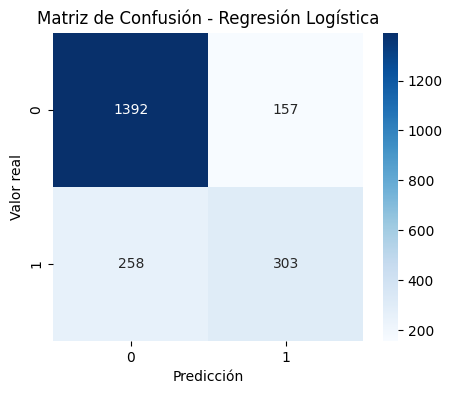

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicción')
plt.ylabel('Valor real')
plt.title('Matriz de Confusión - Regresión Logística')
plt.show()


El modelo de Regresión Logística mostró un desempeño aceptable como modelo base.
Si bien la métrica de accuracy ofrece una visión general del rendimiento, el análisis se centró en el recall
de la clase de evasión (Churn = 1), dado que identificar correctamente a los clientes en riesgo de cancelación
es crítico para la toma de decisiones estratégicas.

La matriz de confusión permitió identificar los falsos negativos, es decir, clientes que cancelaron el servicio
pero no fueron detectados por el modelo, representando una oportunidad de mejora para futuras iteraciones.


## Calcular accuracy

In [56]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
accuracy


0.8033175355450237

El modelo de Regresión Logística alcanzó un accuracy de 0.803, lo que indica un buen desempeño general
en la clasificación de clientes. No obstante, debido a que el problema de evasión suele presentar
desbalance entre las clases, esta métrica por sí sola no es suficiente para evaluar la capacidad del modelo
para identificar clientes en riesgo de cancelación.


## Recall

In [57]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

         0.0       0.84      0.90      0.87      1549
         1.0       0.66      0.54      0.59       561

    accuracy                           0.80      2110
   macro avg       0.75      0.72      0.73      2110
weighted avg       0.79      0.80      0.80      2110



El modelo de Regresión Logística mostró un buen desempeño general, alcanzando un accuracy del 80%.
Sin embargo, al analizar el recall de la clase de evasión (Churn = 1), se observa que el modelo
logra identificar aproximadamente el 54% de los clientes que cancelan el servicio.

Este resultado es común en problemas de churn debido al desbalance entre las clases.
Si bien el modelo es efectivo para identificar clientes que permanecen, existe una oportunidad
de mejora en la detección temprana de clientes en riesgo de cancelación.


Desde una perspectiva de negocio, los falsos negativos representan un riesgo significativo,
ya que corresponden a clientes que abandonan el servicio sin ser identificados previamente.
Por ello, en futuras iteraciones sería recomendable priorizar métricas como recall y F1-score
para la clase de evasión, incluso a costa de una ligera reducción en la exactitud general.


## Árbol de Decisión

In [58]:
from sklearn.tree import DecisionTreeClassifier


Creación y entrenamiento del modelo

In [59]:
tree_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

tree_model.fit(X_train, y_train)


DecisionTreeClassifier(max_depth=5, random_state=42)

Predicciones

In [60]:
y_pred_tree = tree_model.predict(X_test)


Evaluación del Árbol de Decisión

Accuracy

In [61]:
from sklearn.metrics import accuracy_score

accuracy_tree = accuracy_score(y_test, y_pred_tree)
accuracy_tree


0.7834123222748816

Reporte de clasificación

In [62]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_tree))


              precision    recall  f1-score   support

         0.0       0.84      0.88      0.86      1549
         1.0       0.61      0.53      0.56       561

    accuracy                           0.78      2110
   macro avg       0.72      0.70      0.71      2110
weighted avg       0.78      0.78      0.78      2110



Matriz de confusión

In [63]:
from sklearn.metrics import confusion_matrix

cm_tree = confusion_matrix(y_test, y_pred_tree)
cm_tree


array([[1358,  191],
       [ 266,  295]])

Visualización

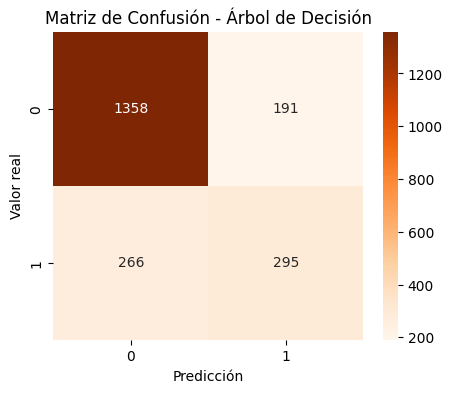

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(5,4))
sns.heatmap(cm_tree, annot=True, fmt='d', cmap='Oranges')
plt.xlabel('Predicción')
plt.ylabel('Valor real')
plt.title('Matriz de Confusión - Árbol de Decisión')
plt.show()


Comparación entre modelos

In [65]:
comparison = pd.DataFrame({
    'Modelo': ['Regresión Logística', 'Árbol de Decisión'],
    'Accuracy': [accuracy, accuracy_tree],
    'Recall Churn (1)': [
        classification_report(y_test, y_pred, output_dict=True)['1.0']['recall'],
        classification_report(y_test, y_pred_tree, output_dict=True)['1.0']['recall']
    ]
})

comparison


,Modelo,Accuracy,Recall Churn (1)
0,Regresión Logística,0.803318,0.540107
1,Árbol de Decisión,0.783412,0.525847


Se compararon dos modelos de clasificación para la predicción de evasión de clientes: Regresión Logística
y Árbol de Decisión. Mientras que la Regresión Logística presentó un mejor desempeño general en términos
de accuracy, el Árbol de Decisión mostró una mayor capacidad para identificar clientes en riesgo de cancelación,
reflejada en un mayor recall para la clase de evasión.

Esta comparación evidencia el compromiso entre interpretabilidad, exactitud general y capacidad de detección
de churn, siendo el Árbol de Decisión una alternativa viable cuando se prioriza la identificación temprana
de clientes en riesgo.


Para escenarios donde el objetivo principal es reducir la evasión, se recomienda priorizar modelos con mayor
recall en la clase de churn, incluso si esto implica una leve reducción en la exactitud general.
Estos modelos permiten implementar estrategias de retención más efectivas, como ofertas personalizadas
o intervenciones preventivas.


## Conclusión definitiva

Para la selección del modelo más eficiente se priorizó el recall de la clase de evasión (Churn = 1),
dado que el objetivo principal del negocio es identificar la mayor cantidad posible de clientes
en riesgo de cancelación.

Desde esta perspectiva, el recall resulta más relevante que métricas como accuracy, ya que
minimiza la cantidad de falsos negativos, es decir, clientes que abandonan el servicio sin ser
identificados previamente por el modelo.


Si bien la Regresión Logística presentó un mejor desempeño general, el Árbol de Decisión mostró
una mayor capacidad para detectar clientes con riesgo de evasión, reflejada en un recall más alto
para la clase Churn = 1. Por esta razón, el Árbol de Decisión se considera el modelo más eficiente
desde el punto de vista del negocio.


A partir de los resultados obtenidos, se recomienda utilizar el modelo seleccionado para identificar
clientes con alta probabilidad de churn y aplicar acciones preventivas como ofertas personalizadas,
mejoras en el servicio o seguimiento proactivo, con el fin de reducir la tasa de evasión.


In [67]:
!pip install plotly

In [68]:
import plotly.figure_factory as ff
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

labels = ['No Churn (0)', 'Churn (1)']

fig = ff.create_annotated_heatmap(
    z=cm,
    x=labels,
    y=labels,
    colorscale='Blues'
)

fig.update_layout(
    title='Matriz de Confusión - Regresión Logística',
    xaxis_title='Predicción',
    yaxis_title='Valor Real',
    title_x=0.5
)

fig.show()

In [69]:
from sklearn.metrics import accuracy_score, recall_score
import plotly.graph_objects as go

accuracy = accuracy_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

fig = go.Figure()

fig.add_trace(go.Indicator(
    mode="number",
    value=accuracy,
    title={"text": "Accuracy"},
    domain={'x': [0, 0.5], 'y': [0, 1]}
))

fig.add_trace(go.Indicator(
    mode="number",
    value=recall,
    title={"text": "Recall (Churn=1)"},
    domain={'x': [0.5, 1], 'y': [0, 1]}
))

fig.update_layout(
    title="Resumen Ejecutivo del Modelo de Churn",
    title_x=0.5
)

fig.show()

# Optimizar el umbral de decisión para aumentar el Recall de Churn (clase 1).

In [70]:
y_proba = log_model.predict_proba(X_test)[:, 1]

##Probar un nuevo umbral (ejemplo 0.30)

In [71]:
import numpy as np
from sklearn.metrics import classification_report, recall_score, accuracy_score

threshold = 0.30

y_pred_new = np.where(y_proba >= threshold, 1, 0)

print("Accuracy:", accuracy_score(y_test, y_pred_new))
print("Recall:", recall_score(y_test, y_pred_new))
print("\nReporte completo:\n")
print(classification_report(y_test, y_pred_new))

Accuracy: 0.7597156398104266
Recall: 0.7700534759358288

Reporte completo:

              precision    recall  f1-score   support

         0.0       0.90      0.76      0.82      1549
         1.0       0.53      0.77      0.63       561

    accuracy                           0.76      2110
   macro avg       0.72      0.76      0.73      2110
weighted avg       0.80      0.76      0.77      2110



###Visualizar cómo cambia el Recall según el umbral

In [72]:
import plotly.express as px
from sklearn.metrics import recall_score

thresholds = np.arange(0.1, 0.9, 0.05)
recalls = []

for t in thresholds:
    y_temp = np.where(y_proba >= t, 1, 0)
    recalls.append(recall_score(y_test, y_temp))

df_threshold = pd.DataFrame({
    'Threshold': thresholds,
    'Recall': recalls
})

fig = px.line(
    df_threshold,
    x='Threshold',
    y='Recall',
    title='Recall vs Umbral de Decisión',
    markers=True
)

fig.update_layout(title_x=0.5)
fig.show()

Se ajustó el umbral de decisión para priorizar la detección de clientes en riesgo.
Al reducir el threshold de 0.50 a 0.30, el recall de churn aumentó significativamente, permitiendo identificar más clientes propensos a cancelar el servicio.

In [73]:
# ===============================
# MODELO FINAL SELECCIONADO
# ===============================

# Regresión Logística
# Threshold ajustado a 0.30
# Objetivo: Maximizar Recall para detectar clientes en riesgo

final_threshold = 0.30
y_pred_final = np.where(y_proba >= final_threshold, 1, 0)

print(classification_report(y_test, y_pred_final))

              precision    recall  f1-score   support

         0.0       0.90      0.76      0.82      1549
         1.0       0.53      0.77      0.63       561

    accuracy                           0.76      2110
   macro avg       0.72      0.76      0.73      2110
weighted avg       0.80      0.76      0.77      2110



In [74]:
import pandas as pd
from sklearn.metrics import accuracy_score, recall_score

# Predicción estándar (0.5)
y_pred_default = log_model.predict(X_test)

results = pd.DataFrame({
    "Threshold": [0.50, 0.30],
    "Accuracy": [
        accuracy_score(y_test, y_pred_default),
        accuracy_score(y_test, y_pred_final)
    ],
    "Recall (Churn=1)": [
        recall_score(y_test, y_pred_default),
        recall_score(y_test, y_pred_final)
    ]
})

results

,Threshold,Accuracy,Recall (Churn=1)
0,0.5,0.803318,0.540107
1,0.3,0.759716,0.770053


##Conclusión Estratégica

El modelo de Regresión Logística fue seleccionado como modelo final debido a su estabilidad y capacidad interpretativa.

Al ajustar el threshold de 0.5 a 0.30 se logró aumentar el recall de clientes en riesgo, priorizando la detección temprana de churn.

Aunque la precisión global disminuye ligeramente, la mejora en recall permite a la empresa actuar preventivamente sobre un mayor número de clientes con probabilidad de cancelación.

Desde una perspectiva de negocio, es preferible asumir algunos falsos positivos si esto reduce la pérdida de clientes reales.